In [1]:
# ── Cell 1: Bootstrap repo root + SPEC_HASH assertion ────────────────────────
# EXPLORATORIO — no es un experimento registrado. No requiere SPEC nuevo.
# Objetivo: verificar si alignment (respuesta del precio al flujo dentro del bin)
# discrimina los 78 pares de Exp10 de forma monotónica.
# Sin inferencia formal. Solo observar la forma.
import hashlib, json, os, sys, time
from pathlib import Path

root = Path.cwd()
for _ in range(10):
    if (root / 'research' / '__init__.py').exists():
        break
    root = root.parent
else:
    raise RuntimeError('repo root not found — launch Jupyter from inside TRADING-BOT/')

os.chdir(root)
sys.path.insert(0, str(root))

from research.experiments.exp10_proxy import CONFIG
assert hashlib.sha256(
    json.dumps(CONFIG, sort_keys=True).encode()
).hexdigest()[:12] == '7a809aaca7f3', 'CONFIG no coincide con spec v1 FROZEN'

print(f'repo root : {root}')
print('SPEC_HASH : 7a809aaca7f3  OK')
print('MODO      : EXPLORATORIO — sin inferencia formal, sin SPEC')

repo root : C:\Users\Lenovo\Documents\TRADING-BOT
SPEC_HASH : 7a809aaca7f3  OK
MODO      : EXPLORATORIO — sin inferencia formal, sin SPEC


In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────
import numpy as np
import pandas as pd

from research.experiments.exp10_proxy import (
    compute_bin_stats,
    detect_events,
    match_controls,
    compute_directed_returns,
    CONFIG,
)

TAPE_PATH    = root / 'data' / 'raw' / 'BTCUSDT_AGGTRADES.csv'
HORIZON_MS   = CONFIG['horizon_primary_ms']   # 300_000 ms = 5 min
BIN_SIZE_MS  = 30_000

print(f'tape      : {TAPE_PATH}')
print(f'horizon   : {HORIZON_MS / 60_000:.0f} min')

tape      : C:\Users\Lenovo\Documents\TRADING-BOT\data\raw\BTCUSDT_AGGTRADES.csv
horizon   : 5 min


In [3]:
# ── Cell 3: Pipeline M1→M4 (∼2–10 min, dominado por I/O del tape) ───────────
t0 = time.time()

tape = pd.read_csv(
    TAPE_PATH,
    usecols=['timestamp_ms', 'price', 'qty', 'side'],
    dtype={'timestamp_ms': np.int64, 'price': np.float64,
           'qty': np.float64, 'side': str},
)
print(f'tape loaded     : {len(tape):>12,} trades  ({time.time()-t0:.1f}s)')

bins_df          = compute_bin_stats(tape)
events_df        = detect_events(bins_df)
matched_pairs_df = match_controls(events_df, bins_df)
returns_df, _    = compute_directed_returns(
    matched_pairs_df,
    tape[['timestamp_ms', 'price']],
    horizon_ms=HORIZON_MS,
)

print(f'N_pairs_valid   : {len(returns_df):>8,}')
print(f'total time      : {time.time()-t0:.1f}s')

tape loaded     :   41,544,041 trades  (14.9s)
N_pairs_valid   :       78
total time      : 47.4s


In [4]:
# ── Cell 4: Calcular p_open y alignment ───────────────────────────────────
# p_open = primer precio del bin (del aggTrade con timestamp_ms mínimo dentro del bin).
# NO se modifica compute_bin_stats ni el pipeline oficial.
# Se computa aquí directamente del tape crudo.

event_tbins = set(returns_df['event_t_bin'].tolist())

# Asignar t_bin a cada trade del tape (sin mutar el tape original)
t_arr  = tape['timestamp_ms'].to_numpy(dtype=np.int64)
px_arr = tape['price'].to_numpy(dtype=np.float64)
bin_arr = (t_arr // BIN_SIZE_MS) * BIN_SIZE_MS

# Filtrar solo los bins de eventos + tomar el primer precio por bin
mask = np.isin(bin_arr, list(event_tbins))
df_filt = pd.DataFrame({'t_bin': bin_arr[mask], 'ts': t_arr[mask], 'price': px_arr[mask]})

p_open_map = (
    df_filt.sort_values('ts')
           .groupby('t_bin')['price']
           .first()
           .to_dict()
)

explore = returns_df.copy()
explore['p_open']     = explore['event_t_bin'].map(p_open_map)
explore['bin_return'] = np.log(explore['event_p0'] / explore['p_open'])
explore['alignment']  = explore['event_sign_W'] * explore['bin_return']
explore['pair_delta'] = explore['event_directed_ret'] - explore['control_directed_ret']

n_missing = explore['p_open'].isna().sum()
print(f'p_open encontrados  : {len(explore) - n_missing}/{len(explore)}')
print(f'alignment  mean     : {explore["alignment"].mean():+.6f}')
print(f'alignment  std      : {explore["alignment"].std():.6f}')
print(f'alignment  range    : [{explore["alignment"].min():+.6f}, {explore["alignment"].max():+.6f}]')

p_open encontrados  : 78/78
alignment  mean     : +0.000792
alignment  std      : 0.000616
alignment  range    : [-0.000296, +0.002779]


In [5]:
# ── Cell 5: Tabla por cuartiles de alignment ──────────────────────────────
# Q1 = más absorbidos (alignment más bajo: precio fue contra el flujo o plano)
# Q4 = más momentum   (alignment más alto: precio siguió al flujo)
#
# Patrón que justifica Exp11: Q1 >> Q4 en Δ_obs (monotónico decreciente).
# Patrón que cierra la familia: sin gradiente claro.

explore['alignment_q'] = pd.qcut(
    explore['alignment'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4']
)

print('Exp10 Post-mortem — Absorción (EXPLORATORIO, sin inferencia formal)')
print('=' * 68)
print(f'  {"Cuartil":<8}  {"N":>3}  {"alignment_med":>13}  {"align_rng":>20}  {"Δ_obs":>10}')
print(f'  {"-"*8}  {"-"*3}  {"-"*13}  {"-"*20}  {"-"*10}')

deltas = []
for q in ['Q1', 'Q2', 'Q3', 'Q4']:
    seg   = explore[explore['alignment_q'] == q]
    delta = float(seg['pair_delta'].mean())
    deltas.append(delta)
    ali_lo  = seg['alignment'].min()
    ali_hi  = seg['alignment'].max()
    ali_med = seg['alignment'].median()
    rng_str = f'[{ali_lo:+.5f}, {ali_hi:+.5f}]'
    print(f'  {q:<8}  {len(seg):>3}  {ali_med:>+13.6f}  {rng_str:>20}  {delta:>+10.6f}')

# ── Diagnóstico de gradiente ──
print()
q1_to_q4 = f'{[f"{d:+.6f}" for d in deltas]}'
is_monotonic_dec = all(deltas[i] >= deltas[i+1] for i in range(3))
q1_beats_q4      = deltas[0] > deltas[3]

if is_monotonic_dec and q1_beats_q4:
    verdict = 'GRADIENTE MONOTÓNICO ↓  → apertura de Exp11 justificada'
elif q1_beats_q4:
    verdict = 'Q1 > Q4 pero no monotónico → evidencia débil, evaluar caso a caso'
else:
    verdict = 'SIN GRADIENTE CLARO  → familia de absorción probablemente cerrada'

print(f'  Q1→Q4 deltas : {q1_to_q4}')
print(f'  VEREDICTO    : {verdict}')
print('=' * 68)

Exp10 Post-mortem — Absorción (EXPLORATORIO, sin inferencia formal)
  Cuartil     N  alignment_med             align_rng       Δ_obs
  --------  ---  -------------  --------------------  ----------
  Q1         20      +0.000175  [-0.00030, +0.00034]   +0.000574
  Q2         19      +0.000507  [+0.00035, +0.00073]   +0.000236
  Q3         19      +0.000943  [+0.00074, +0.00113]   -0.000905
  Q4         20      +0.001426  [+0.00115, +0.00278]   -0.000309

  Q1→Q4 deltas : ['+0.000574', '+0.000236', '-0.000905', '-0.000309']
  VEREDICTO    : Q1 > Q4 pero no monotónico → evidencia débil, evaluar caso a caso


In [6]:
# ── Cell 6: Cuantificación alignment → pair_delta ─────────────────────────
# EXPLORATORIO. Hipótesis-generación sobre los MISMOS 78 eventos de Exp10.
# NO es confirmación: todo p-valor aquí es POST-HOC (garden of forking paths).
# Sirve solo para decidir si vale un Exp11 PRE-REGISTRADO sobre tape NUEVO.
#
# Confound bid-ask bounce: la reversión microestructural predeciría correlación
# POSITIVA alignment↔pair_delta. El gradiente observado es NEGATIVO ⇒ el ruido
# microestructural va EN CONTRA del gradiente, no lo fabrica.
from scipy import stats

x = explore['alignment'].to_numpy(dtype=float)
y = explore['pair_delta'].to_numpy(dtype=float)
n = len(x)
print(f'N = {n}\n')

# ── 1. Spearman (rango — robusto a outliers; PRIMARIO dado el riesgo de Q3) ──
rho, p_rho   = stats.spearmanr(x, y)
r_pear, p_pe = stats.pearsonr(x, y)
print(f'Spearman rho = {rho:+.4f}   p = {p_rho:.4f}   (primario, robusto)')
print(f'Pearson  r   = {r_pear:+.4f}   p = {p_pe:.4f}   (referencia, sensible a outliers)')
print(f'Signo esperado por hipótesis de absorción: NEGATIVO (alto alignment → menos reversión)\n')

# ── 2. Regresión lineal  pair_delta = a + b·alignment ──
lr    = stats.linregress(x, y)
tcrit = stats.t.ppf(0.975, df=n - 2)
ci    = (lr.slope - tcrit * lr.stderr, lr.slope + tcrit * lr.stderr)
print('Regresion  pair_delta = a + b*alignment')
print(f'  slope b   = {lr.slope:+.4f}   IC95 [{ci[0]:+.4f}, {ci[1]:+.4f}]   '
      f'{"(IC cruza 0)" if ci[0] < 0 < ci[1] else "(IC no cruza 0)"}')
print(f'  intercept = {lr.intercept:+.6f}')
print(f'  R^2       = {lr.rvalue**2:.4f}   p_slope = {lr.pvalue:.4f}\n')

# ── 3. Split binario en la mediana de alignment (permutacion, no asintotico) ──
med  = np.median(x)
low  = y[x <  med]
high = y[x >= med]
diff_obs = high.mean() - low.mean()
rng  = np.random.default_rng(7)
pool = np.r_[low, high]; nlow = len(low)
perm = np.array([(lambda s: s[nlow:].mean() - s[:nlow].mean())(rng.permutation(pool))
                 for _ in range(10_000)])
p_split = (np.abs(perm) >= abs(diff_obs)).mean()
print(f'Split en mediana alignment = {med:+.6f}')
print(f'  low  (n={len(low)}) mean pair_delta = {low.mean():+.6f}')
print(f'  high (n={len(high)}) mean pair_delta = {high.mean():+.6f}')
print(f'  diff (high-low)                = {diff_obs:+.6f}   p_perm = {p_split:.4f}\n')

# ── 4. Robustez a outliers ──
def spear_trim(xx, yy, k=2):
    keep = np.argsort(xx)[k:-k]
    return stats.spearmanr(xx[keep], yy[keep])[0]
keep_y = np.argsort(y)[2:-2]
print('Robustez:')
print(f'  Spearman sin 2 alignment extremos  = {spear_trim(x, y):+.4f}')
print(f'  Spearman sin 2 pair_delta extremos = {stats.spearmanr(x[keep_y], y[keep_y])[0]:+.4f}')
q3 = np.sort(explore.loc[explore['alignment_q'] == 'Q3', 'pair_delta'].to_numpy())
print(f'  Q3 pair_delta ordenado: {np.round(q3, 6)}')
print(f'  Q3 mean={q3.mean():+.6f}  median={np.median(q3):+.6f}  '
      f'({"media~mediana -> no es 1-2 outliers" if abs(q3.mean()-np.median(q3)) < 0.0003 else "media!=mediana -> revisar outliers"})')

# ── Magnitud tradable (el gate real, independiente de la significancia) ──
print(f'\n|pair_delta| mediano = {np.median(np.abs(y))*1e4:.1f} bps  '
      f'(vs piso de costos ~varios bps que mato a M1)')

N = 78

Spearman rho = -0.1733   p = 0.1292   (primario, robusto)
Pearson  r   = -0.0974   p = 0.3963   (referencia, sensible a outliers)
Signo esperado por hipótesis de absorción: NEGATIVO (alto alignment → menos reversión)

Regresion  pair_delta = a + b*alignment
  slope b   = -0.4668   IC95 [-1.5566, +0.6230]   (IC cruza 0)
  intercept = +0.000275
  R^2       = 0.0095   p_slope = 0.3963

Split en mediana alignment = +0.000737
  low  (n=39) mean pair_delta = +0.000409
  high (n=39) mean pair_delta = -0.000600
  diff (high-low)                = -0.001009   p_perm = 0.1354

Robustez:
  Spearman sin 2 alignment extremos  = -0.1778
  Spearman sin 2 pair_delta extremos = -0.1444
  Q3 pair_delta ordenado: [-0.006607 -0.005152 -0.004854 -0.004155 -0.002938 -0.002618 -0.001367
 -0.001012 -0.000782 -0.000574  0.00026   0.000516  0.000639  0.000793
  0.000873  0.000995  0.001547  0.00204   0.005195]
  Q3 mean=-0.000905  median=-0.000574  (media!=mediana -> revisar outliers)

|pair_delta| media

figura guardada: C:\Users\Lenovo\Documents\TRADING-BOT\research\experiments\outputs\exp10_absorption_scatter.png
Lectura: pendiente roja negativa + binned means escalonados hacia abajo = señal coherente.
         nube plana / binned means sin orden = ruido → cerrar familia.


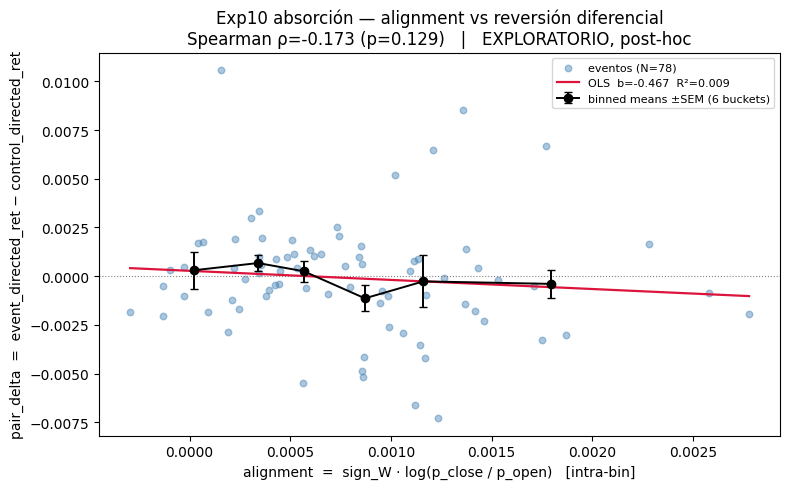

In [7]:
# ── Cell 7: Scatter alignment vs pair_delta + binned means + recta OLS ─────
# Visual. Mismo dataframe `explore`. Depende de la Cell 6 (usa lr, rho).
import matplotlib.pyplot as plt

# binned means en 6 buckets por cuantil de alignment (SEM como barra de error)
nb = 6
explore['_b'] = pd.qcut(explore['alignment'], q=nb, labels=False, duplicates='drop')
g  = explore.groupby('_b')
bx = g['alignment'].mean().to_numpy()
by = g['pair_delta'].mean().to_numpy()
be = (g['pair_delta'].std() / np.sqrt(g['pair_delta'].count())).to_numpy()

fig, ax = plt.subplots(figsize=(8, 5))
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.scatter(x, y, s=22, alpha=0.45, color='steelblue', label=f'eventos (N={n})')
xs = np.linspace(x.min(), x.max(), 100)
ax.plot(xs, lr.intercept + lr.slope * xs, color='crimson', lw=1.6,
        label=f'OLS  b={lr.slope:+.3f}  R²={lr.rvalue**2:.3f}')
ax.errorbar(bx, by, yerr=be, fmt='o-', color='black', lw=1.4, ms=6,
            capsize=3, label='binned means ±SEM (6 buckets)')
ax.set_xlabel('alignment  =  sign_W · log(p_close / p_open)   [intra-bin]')
ax.set_ylabel('pair_delta  =  event_directed_ret − control_directed_ret')
ax.set_title(f'Exp10 absorción — alignment vs reversión diferencial\n'
             f'Spearman ρ={rho:+.3f} (p={p_rho:.3f})   |   EXPLORATORIO, post-hoc')
ax.legend(fontsize=8, loc='best')
fig.tight_layout()

out = root / 'research' / 'experiments' / 'outputs' / 'exp10_absorption_scatter.png'
fig.savefig(out, dpi=130)
print(f'figura guardada: {out}')
print('Lectura: pendiente roja negativa + binned means escalonados hacia abajo = señal coherente.')
print('         nube plana / binned means sin orden = ruido → cerrar familia.')
plt.show()